# Koneoppimisprojekti

## 1. Business Understanding

Projektin tavoitteena on tutkia Turun AMK:n opinnäytetöihin liittyvää dataa koneoppimisen metodien avulla.

Tavoite jakautuu seuraaviin tutkimuskysymyksiin:

Mitkä opinnäytetyön ominaisuudet vaikuttavat eniten arvosanaan?
Kuinka tarkasti opinnäytetyön arvosana voidaan ennustaa pelkästään työn rakenteellisten ominaisuuksien perusteella?
Voidaanko lähteiden laadun perusteella ennustaa opinnäytetyön arvosana?
Kuinka paljon sivumäärä ja sanamäärä selittävät opinnäytetyön arvosanaa?

## 2. Data Understanding

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
# Lue data, luo yksi dataframe-objekti

df_en = pd.read_csv('./data/output_en.csv')
df_fi = pd.read_csv('./data/output_fi.csv')
df = pd.concat([df_en, df_fi], ignore_index=True)
df = df.fillna(0)

# Korjaa datatyypit

df["Total References"] = df["Total References"].astype(int)
df["Internet References"] = df["Internet References"].astype(int)
df["Printed References"] = df["Printed References"].astype(int)
df["Weak References"] = df["Weak References"].astype(int)
df["Pages"] = df["Pages"].astype(int)
df["Total Word Count"] = df["Total Word Count"].astype(int)
df["Study Credits"] = df["Study Credits"].astype(int)


In [46]:
# Korrelaatiomatriisi

corr = df.drop(columns=["Keywords"]).corr()
corr


,Total References,Internet References,Printed References,Weak References,Pages,Total Word Count,Study Credits,Study Entitlement Days,Grade,Supervisor ID,Total Occurrences
Total References,1.000000,0.665492,0.724367,0.313508,0.348487,0.306185,0.271505,0.011294,0.233368,-0.012685,0.091016
Internet References,0.665492,1.000000,0.098428,0.454934,0.200428,0.176914,0.054383,0.003586,0.158539,-0.017057,0.044474
Printed References,0.724367,0.098428,1.000000,0.071330,0.315973,0.295928,0.326520,0.025623,0.180772,-0.002392,0.026535
Weak References,0.313508,0.454934,0.071330,1.000000,0.104979,0.152794,-0.004606,-0.048046,-0.010637,-0.065544,0.033955
Pages,0.348487,0.200428,0.315973,0.104979,1.000000,0.792351,0.359071,-0.052931,0.414430,-0.027055,0.342714
Total Word Count,0.306185,0.176914,0.295928,0.152794,0.792351,1.000000,0.257820,-0.102319,0.365301,-0.042977,0.324485
Study Credits,0.271505,0.054383,0.326520,-0.004606,0.359071,0.257820,1.000000,-0.005449,0.120830,0.033804,0.302714
Study Entitlement Days,0.011294,0.003586,0.025623,-0.048046,-0.052931,-0.102319,-0.005449,1.000000,-0.121762,0.003782,0.057780
Grade,0.233368,0.158539,0.180772,-0.010637,0.414430,0.365301,0.120830,-0.121762,1.000000,-0.175320,0.114454
Supervisor ID,-0.012685,-0.017057,-0.002392,-0.065544,-0.027055,-0.042977,0.033804,0.003782,-0.175320,1.000000,-0.004752


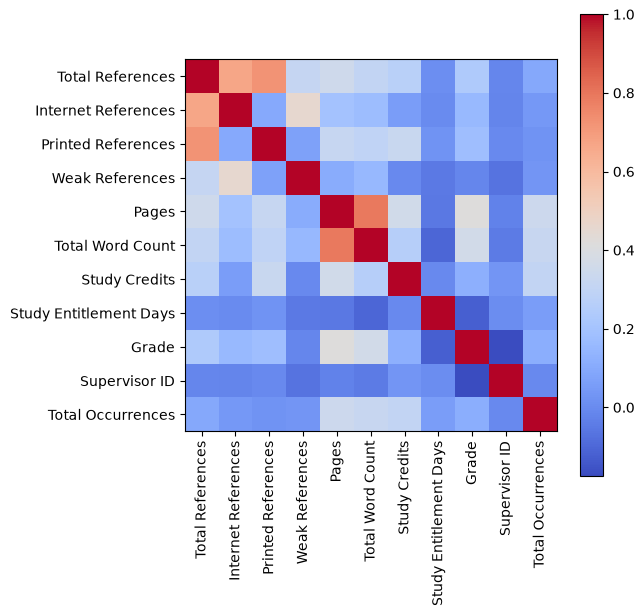

In [50]:
plt.figure(figsize=(6, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

In [55]:
# Keskimääräinen arvosana valvojaa kohden

grades = df.groupby("Supervisor ID")["Grade"].agg(average_grade="mean", n_theses="count")
grades = grades[grades["n_theses"] >= 10]
grades

,average_grade,n_theses
Supervisor ID,,
1,3.681818,44
2,4.088235,34
3,3.312500,32
4,4.230769,13
5,3.303030,33
10,3.250000,12
13,3.900000,20
20,3.173077,52
22,3.636364,11
